# Visualizing NRL list mode data
The NRL list mode for EXACT requires a bit of calibration to ensure that the relative detector time stamps are aligned with GPS time.

## Example data is [here](https://drive.google.com/file/d/1I1d0L3IgfpkFf7QadZMnqb88V1NUwVhJ).

## How to: convert raw binary files into more useful data
1. Take data following the EXACT procedure in the docs
2. Copy the data files over to your computer using the `scp` command.
The files are named `detsci-list-*.bin.gz` where `*` has stuff like the date the file was created in it,
and which detector channel is being referenced.
3. Run the `decode-exact-science` executible on the data.
This executible is referenced like a script after you install the `umndet` Python package from this repository.
Here is an example of how to run it:
```bash
decode-exact-science --help
# Output:
# usage: decode-exact-science [-h] files [files ...] output_fn
# 
# Decode EXACT science files to JSON
# 
# positional arguments:
#   files       files to decode to JSON
#   output_fn   output file name to write JSON
# 
# options:
#   -h, --help  show this help message and exit

# Say your data files are in the following directory
cd data_files
# Run the script here and output to a compressed JSON
decode-exact-science detsci-list*.bin.gz decoded_exact.json.gz
```

The data file produced, `decoded_exact.json.gz`, is JSON data compressed using gzip.
The JSON is compressed because storing it as text takes up a lot of space.
Feel free to `gunzip` the file to see the space difference.

4. Once you have the file `decoded_exact.json.gz`, you can open it and plot the data like in this Jupyter notebook

In [13]:
import datetime
import gzip
import json

import matplotlib.pyplot as plt

plt.style.use("style")
%matplotlib inline

In [14]:
fn = "exact/exact.json.gz"
with gzip.open(fn) as f:
    data = json.loads(f.read().decode("utf-8"))

In [15]:
# See what each data point has inside of it
data[0]

{'psd': 2254,
 'energy': 33113,
 'external_trigger': 0,
 'piled_up': 1,
 'over_flow': 0,
 'out_of_range': 0,
 'was_pps': 0,
 'padding': 0,
 'anchor_time': 1790525096,
 'anchor_ns_delta': -89773330275}

- The `anchor_time` is the UNIX timestamp of the last PPS in the buffer.
- The `anchor_ns_delta` is the difference between that anchor time and the event timestamp,
    as reported by the Bridgeport.
    Importantly,
    no attempt to correct for clock drift has been made.

In [16]:
# Most things we don't care about...for now
# Let's separate out the PPS events
energies = []
times = []

pps_times = []
for i, evt in enumerate(data):
    if evt["was_pps"]:
        pps_times.append(
            datetime.datetime.fromtimestamp(
                evt["anchor_time"] + (evt["anchor_ns_delta"] / 1e9), datetime.UTC
            )
        )
        continue

    # We don't have a PPS event
    energies.append(evt["energy"])
    times.append(
        datetime.datetime.fromtimestamp(
            evt["anchor_time"] + (evt["anchor_ns_delta"] / 1e9), datetime.UTC
        )
    )

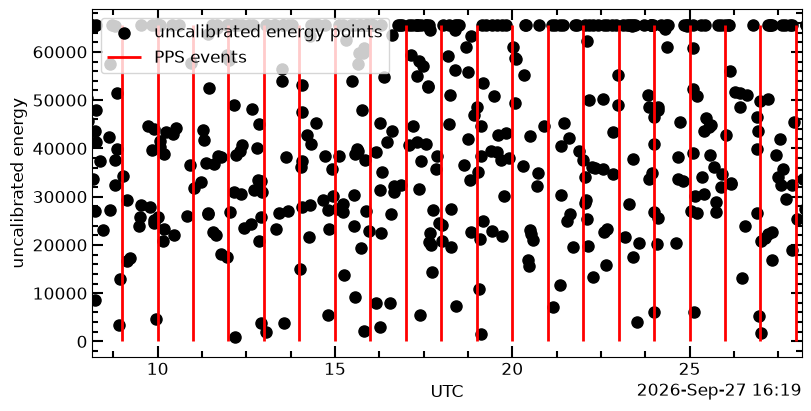

In [17]:
# Use qt for interactive
# %matplotlib qt

# Use inline for static
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(times, energies, color="black", label="uncalibrated energy points")
ax.vlines(pps_times, ymin=0, ymax=2**16, color="red", label="PPS events")
ax.legend(loc="upper left")
ax.set(
    xlabel="UTC",
    ylabel="uncalibrated energy",
    # Put the xlim right in the middle of the data
    xlim=(ta := times[len(times) // 2], ta + datetime.timedelta(seconds=20)),
)
plt.show()